In [1]:
from classifier import *
import pandas as pd
import warnings
warnings.filterwarnings("ignore") # suppress all warnings

In [2]:
generate_embeddings("data", "hubert")

Generating embeddings layer-wise: 100%|████████| 25/25 [00:00<00:00, 233.15it/s]


In [3]:
hubert_df = classify_phonation_mode("hubert")
hubert_df.to_csv('results/hubert_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|████████████████| 25/25 [00:02<00:00,  8.80it/s]


# SVM

## Stratified K-Fold Cross Validation

In [2]:
hubert_5fold_df, confusion_matrices = k_fold_cross_val("hubert")
hubert_5fold_df.to_csv('results/hubert_5fold_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|████████████████| 25/25 [00:19<00:00,  1.26it/s]


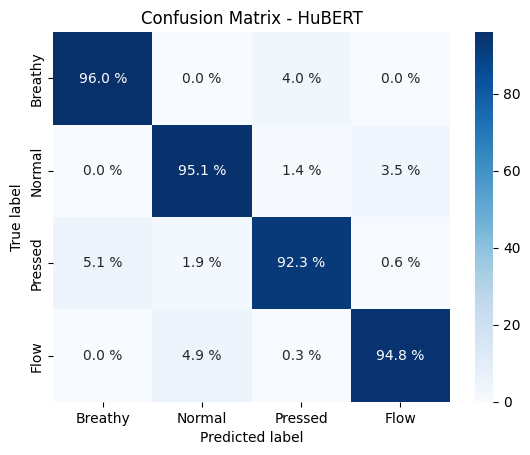

In [3]:
layer_num=4
combined_cm = None
class_labels = ["Breathy", "Normal", "Pressed", "Flow"]
for layer, fold, cm in confusion_matrices:
    if layer_num is None or layer == layer_num:
        if combined_cm is None:
            combined_cm = cm
        else:
            combined_cm += cm

if combined_cm is not None:
    # Calculate percentages
    cm_sum = np.sum(combined_cm, axis=1, keepdims=True)
    combined_cm_percentage = np.round(100 * combined_cm / cm_sum, 2)

    plt.figure()
    plot = sns.heatmap(combined_cm_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    for t in plot.texts: t.set_text(t.get_text() + " %")
    plt.title(f'Confusion Matrix - HuBERT')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    
    # Save the plot as SVG
    plt.savefig('results/confusion_matrix_hubert.svg', format='svg')
    
    plt.show()

## Hyper-parameter Tuning

In [6]:
model_name = "hubert"
layer=4
param_grid = {
    'C': [0.001, 0.01, 0.1],
    'gamma': [0.0000001, 0.000001, 0.00001, 0.0001, 0.001, 'scale'],
}

# Perform hyperparameter tuning
best_params, best_score = svm_hyperparameter_tuning(model_name, layer, param_grid)

print("Best hyperparameters:", best_params)
print("Best cross-validation score:", best_score)

Best hyperparameters: {'C': 0.01, 'gamma': 1e-07}
Best cross-validation score: 0.9501547987616099


## Tuned Model Evaluation

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [8]:
model_name = "hubert"
layer=4
folder_path = "embeddings/" + model_name + "/" + str(layer) + "/"
X = np.load(os.path.join(folder_path, "X.npy"), allow_pickle=True)
y = np.load(os.path.join(folder_path, "y.npy"), allow_pickle=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

# Train SVM classifier
svm_classifier = SVC(kernel='linear', C=0.001, gamma=0.00001)
svm_classifier.fit(X_train, y_train)

# Evaluate classifier
y_pred = svm_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', accuracy)

# Create a DataFrame to store results for the current layer
layer_results_df = pd.DataFrame({
    'Actual_Label': y_test,
    'Predicted_Label': y_pred,
    'Layer': layer
})

Accuracy:  0.9477124183006536


# Neural Net

In [9]:
hubert_5fold_nn_df = k_fold_cross_val_nn("hubert")
hubert_5fold_nn_df.to_csv('results/hubert_5fold_nn_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|████████████████| 25/25 [01:15<00:00,  3.03s/it]


# XGB

In [10]:
hubert_5fold_xgb_df = k_fold_cross_val_xgb("hubert")
hubert_5fold_xgb_df.to_csv('results/hubert_5fold_xgb_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|████████████████| 25/25 [09:49<00:00, 23.59s/it]


## dev archive/notes

### experiments

- HuBERT ✅
- investigate earlier hidden_states (https://www.sciencedirect.com/science/article/pii/S0885230823000694) ✅


- different classifier ❌ _data limit for DL models_
- wav2vec-base ✅
- wav2vec-large ✅
- investigate all hidden_states ✅


- histogram of the length of the wav files by phonation mode ✅
- consider trimmings instead of padding ✅
- norm wav freq and amplitude w/ librosa ✅
- do 5-fold CV - find correct CV algo from sklearn ✅


- change to stratified kfold ✅
- plot also std along with mean ✅
- confusion mat plot ✅ - CHANGE TO BE WITHIN KFOLD and ADD ALL THE VALUES
- store all the embeddings as np arrays ✅
- Grid search for hyper param tuning - HuBERT ✅
- attempt to find average of all the embeddings ⚠️
- explore models specifically for singings (or using singing data) ➖

### todo for paper:
- experi setup
- experiments
- results